In [2]:
import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
data = tf.keras.datasets.mnist.load_data()
classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 11s 1us/step


In [4]:
(train_images, train_labels), (test_images, test_labels) = data


In [5]:
print("Train Images:", train_images.shape)
print("Train Labels:", train_labels.shape)
print("Test Images:", test_images.shape)
print("Test Labels:", test_labels.shape)

Train Images: (60000, 28, 28)
Train Labels: (60000,)
Test Images: (10000, 28, 28)
Test Labels: (10000,)


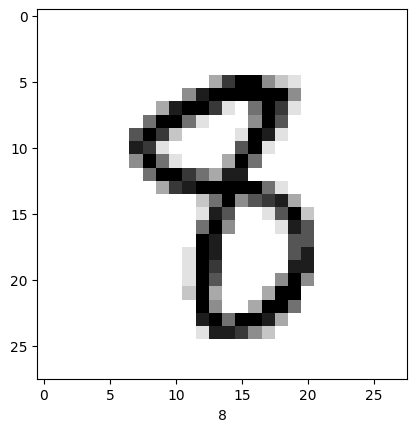

In [6]:
rndm = np.random.randint(0, len(train_images))
plt.xlabel(classes[train_labels[rndm]])
plt.imshow(train_images[rndm], cmap=plt.cm.binary)

In [7]:
train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

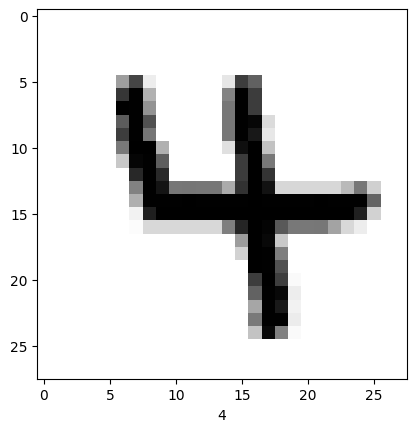

In [8]:
rndm = np.random.randint(0, len(train_images))
plt.xlabel(classes[train_labels[rndm]])
plt.imshow(train_images[rndm], cmap=plt.cm.binary)

In [9]:
print("pixel_value:")
for row in train_images[rndm]:
    for pixel in row:
        print("{:0.3f}".format(pixel), end=" ")
    print()

pixel_value:
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.184 0.443 0.886 0.573 0.522 0.275 0.047 0.278 0.196 0.408 0.380 0.600 0.573 0.302 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.008 0.000 0.337 0.659 0.914 0.557 0.506 0.459 0.549 0.714 0.863 0.839 0.808 0.718 0.361 0.714 0.757 0.569 0.584 0.384 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.102 0.780 0.769 0.533 0.820 0.745 0.090 0.651 0.635 0.667 0.729 0.298 0.690 0.616 0.322 0.361 0.655 0.741 0.812 0.169 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.992 0.490 0.478 0.698 0.451 0.502 0.475 0.639 0.537 0.694 0.863 0.682 0.518 0.612 0.416 1.000 0.776 0.804 0.588 0.490 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.012 0.655 0.420 0.800 0.467 0.800 0.278 0.000 0.647 0.490 0.416 0.616 0.325 0.745 0.365 0.000 0.384 0.573 0.831 0.714 0.353 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.353 0.341 0.255 0.678 0.671 0.318 1.000 0.769 0.000 0.620 0.439 0.149 0.757 0.086 0.333 0.486 0.859 0.600 0.749 0.420 1.00

In [9]:
#reshape images to (28, 28, 1)
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [101]:
#create model


model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3),activation='relu'),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,138 (547.41 KB)

 Trainable params: 140,138 (547.41 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
model.fit(train_images, train_labels, epochs=30, validation_data=(test_images, test_labels))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9603 - loss: 0.1052 - val_accuracy: 0.9131 - val_loss: 0.3018
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9651 - loss: 0.0921 - val_accuracy: 0.9085 - val_loss: 0.3091
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9680 - loss: 0.0848 - val_accuracy: 0.9154 - val_loss: 0.3077
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9713 - loss: 0.0759 - val_accuracy: 0.9167 - val_loss: 0.3306
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9752 - loss: 0.0670 - val_accuracy: 0.9114 - val_loss: 0.3673
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9766 - loss: 0.0636 - val_accuracy: 0.9162 - val_loss: 0.3585
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9774 - loss: 0.0603 - val_accuracy: 0.9148 - val_loss: 0.3610
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9791 - loss

KeyboardInterrupt: 

In [104]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)   

313/313 - 1s - 3ms/step - accuracy: 0.9092 - loss: 0.5361
Test Loss: 0.5360994338989258
Test Accuracy: 0.9092000126838684


In [96]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [97]:
i = np.random.randint(0, len(test_images))
print("Predicted Label:", np.argmax(predictions[i]))
print("Actual Label:", test_labels[i])

Predicted Label: 4
Actual Label: 4


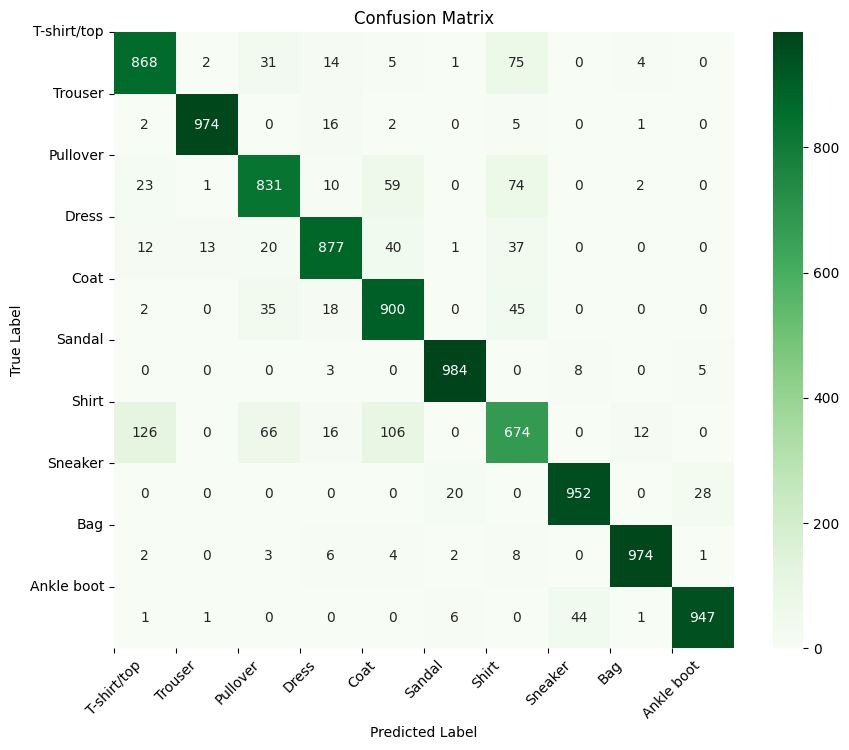

In [ ]:

cm = confusion_matrix(test_labels, np.argmax(predictions, axis=1))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45)
plt.yticks(np.arange(len(classes)), classes, rotation=0)
plt.title("Confusion Matrix")
plt.show()

In [98]:
model.save("fashion_mnist_model.keras")